In [1]:
import zipfile
from pathlib import Path

zip_path = Path("../data/raw/heart+disease.zip")

print("ZIP exists:", zip_path.exists())
print("ZIP path:", zip_path)

ZIP exists: True
ZIP path: ..\data\raw\heart+disease.zip


In [2]:
import zipfile
from pathlib import Path

zip_path = Path("../data/raw/heart+disease.zip")
extract_path = Path("../data/raw/heart-disease")

extract_path.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Files:")
for file in extract_path.rglob("*"):
    if file.is_file():
        print(file)

Dataset extracted successfully!
Files:
..\data\raw\heart-disease\ask-detrano
..\data\raw\heart-disease\bak
..\data\raw\heart-disease\cleve.mod
..\data\raw\heart-disease\cleveland.data
..\data\raw\heart-disease\heart-disease.names
..\data\raw\heart-disease\hungarian.data
..\data\raw\heart-disease\Index
..\data\raw\heart-disease\long-beach-va.data
..\data\raw\heart-disease\new.data
..\data\raw\heart-disease\processed.cleveland.data
..\data\raw\heart-disease\processed.hungarian.data
..\data\raw\heart-disease\processed.switzerland.data
..\data\raw\heart-disease\processed.va.data
..\data\raw\heart-disease\reprocessed.hungarian.data
..\data\raw\heart-disease\switzerland.data
..\data\raw\heart-disease\WARNING
..\data\raw\heart-disease\costs\heart-disease.cost
..\data\raw\heart-disease\costs\heart-disease.delay
..\data\raw\heart-disease\costs\heart-disease.expense
..\data\raw\heart-disease\costs\heart-disease.group
..\data\raw\heart-disease\costs\heart-disease.README
..\data\raw\heart-disease\

In [3]:
from pathlib import Path

data_path = Path("../data/raw/heart-disease")

files = [f for f in data_path.iterdir() if f.is_file()]

print("Number of files:", len(files))
print("\nFiles:")
for file in files:
    print("-", file.name)

Number of files: 16

Files:
- ask-detrano
- bak
- cleve.mod
- cleveland.data
- heart-disease.names
- hungarian.data
- Index
- long-beach-va.data
- new.data
- processed.cleveland.data
- processed.hungarian.data
- processed.switzerland.data
- processed.va.data
- reprocessed.hungarian.data
- switzerland.data
- WARNING


In [4]:
### exploring the dataset
import pandas as pd
from pathlib import Path
data_path = Path("../data/raw/heart-disease/processed.cleveland.data")
df = pd.read_csv(data_path, header = None)
print("Shape:", df.shape)
df.head()

Shape: (303, 14)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
### creating columns for the dataset
columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df.columns = columns

df.head()
#| Our column | UCI meaning                       |
#| ---------- | --------------------------------- |
#| `age`      | Age                               |
#| `sex`      | Sex                               |
#| `cp`       | Chest pain type                   |
#| `trestbps` | Resting blood pressure            |
#| `chol`     | Serum cholesterol                 |
#| `fbs`      | Fasting blood sugar >120 mg/dL    |
#| `restecg`  | Resting ECG results               |
#| `thalach`  | Maximum heart rate achieved       |
#| `exang`    | Exercise-induced angina           |
#| `oldpeak`  | ST depression                     |
#| `slope`    | Slope of peak exercise ST segment |
#| `ca`       | Number of major vessels (0–3)     |
#| `thal`     | Thalassemia result                |
#| `target`   | Heart-disease diagnosis           |


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [6]:
### data analysis
print(df.info())
### trying to find the missing value in the dataset
print("\nmissing values:")
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB
None

missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtyp

In [7]:
print("Missing values represented by '?':")
print((df == "?").sum())

Missing values represented by '?':
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [8]:
print("\nRows containing '?':")
print(df[df == "?"].dropna(how="all"))


Rows containing '?':
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
87   NaN  NaN NaN       NaN   NaN  NaN      NaN      NaN    NaN      NaN   
166  NaN  NaN NaN       NaN   NaN  NaN      NaN      NaN    NaN      NaN   
192  NaN  NaN NaN       NaN   NaN  NaN      NaN      NaN    NaN      NaN   
266  NaN  NaN NaN       NaN   NaN  NaN      NaN      NaN    NaN      NaN   
287  NaN  NaN NaN       NaN   NaN  NaN      NaN      NaN    NaN      NaN   
302  NaN  NaN NaN       NaN   NaN  NaN      NaN      NaN    NaN      NaN   

     slope   ca thal  target  
87     NaN  NaN    ?     NaN  
166    NaN    ?  NaN     NaN  
192    NaN    ?  NaN     NaN  
266    NaN  NaN    ?     NaN  
287    NaN    ?  NaN     NaN  
302    NaN    ?  NaN     NaN  


In [9]:
print("CA values:")
print(df["ca"].value_counts())

print("\nThal values:")
print(df["thal"].value_counts())

CA values:
ca
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: count, dtype: int64

Thal values:
thal
3.0    166
7.0    117
6.0     18
?        2
Name: count, dtype: int64


In [10]:
# Convert '?' into proper missing values
import numpy as np
df = df.replace("?", np.nan)

print("Missing values after replacing '?':")
print(df.isnull().sum())
print(df.dtypes)

Missing values after replacing '?':
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca              str
thal            str
target        int64
dtype: object


In [11]:
# Convert categorical-looking numeric columns to numeric
df["ca"] = pd.to_numeric(df["ca"])
df["thal"] = pd.to_numeric(df["thal"])

print(df.dtypes)

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object


In [12]:
# Fill missing values using the mode
df["ca"] = df["ca"].fillna(df["ca"].mode()[0])
df["thal"] = df["thal"].fillna(df["thal"].mode()[0])

print("Missing values after imputation:")
print(df.isnull().sum())
### reason for using mode to fill missing values --- ca and thal are categorical/ordinal clinical variables, even though they're represented numerically. Using the most frequent category is reasonable for these few missing entries and avoids throwing away patient records.

Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [13]:
### checking fir duplicate rows
duplicate_count = df.duplicated().sum()
print(duplicate_count)

0


In [14]:
# Display duplicate rows if any exist
if duplicate_count > 0:
    print(df[df.duplicated()])
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [15]:
### target distribution
print(" Target distribution: ")
print(df["target"].value_counts())

print("\nTarget percentage")
print(df["target"].value_counts(normalize=True) * 100)

 Target distribution: 
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Target percentage
target
0    54.125413
1    18.151815
2    11.881188
3    11.551155
4     4.290429
Name: proportion, dtype: float64


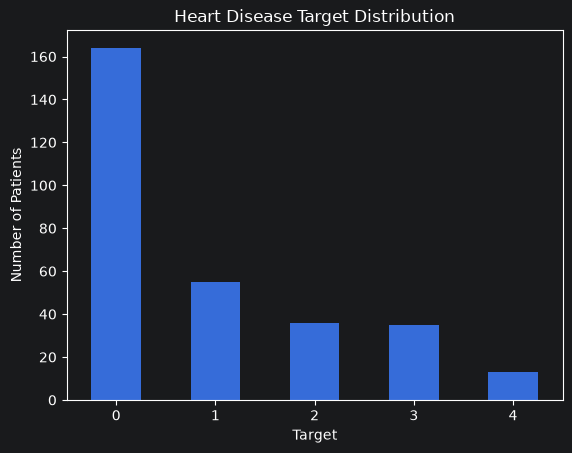

In [16]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar")

plt.title("Heart Disease Target Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

In [17]:
# Convert target into binary classification
# 0 = No heart disease
# 1 = Heart disease (original target 1-4)

df["target"] = (df["target"] > 0).astype(int)

print("New target distribution:")
print(df["target"].value_counts())

print("\nTarget percentages:")
print(df["target"].value_counts(normalize=True) * 100)

New target distribution:
target
0    164
1    139
Name: count, dtype: int64

Target percentages:
target
0    54.125413
1    45.874587
Name: proportion, dtype: float64


In [18]:
### checking number of the duplicates
print(" number of duplicates:", df.duplicated().sum())

 number of duplicates: 0


In [19]:
### seperating features X and the target y
X = df.drop("target", axis=1)
y = df["target"]
print(" features shape", X.shape)
print(" target shape" , y.shape)
print("\n features")
print(X.columns.tolist())
print("target distribution:")
print(y.value_counts())


 features shape (303, 13)
 target shape (303,)

 features
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
target distribution:
target
0    164
1    139
Name: count, dtype: int64


In [20]:
### data splitting
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("training features", X_train.shape)
print("testing features" , X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

training features (242, 13)
testing features (61, 13)

Training target distribution:
target
0    131
1    111
Name: count, dtype: int64

Testing target distribution:
target
0    33
1    28
Name: count, dtype: int64


In [21]:
print("ca values:")
print(sorted(X["ca"].unique()))

print("\nthal values:")
print(sorted(X["thal"].unique()))

ca values:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]

thal values:
[np.float64(3.0), np.float64(6.0), np.float64(7.0)]


In [22]:
### defining features as per groups
categorical_features = ["ca", "thal"]

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

binary_features = [
    "sex",
    "fbs",
    "exang"
]

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)
print("Binary:", binary_features)

Categorical: ['ca', 'thal']
Numerical: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Binary: ['sex', 'fbs', 'exang']


In [23]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully.")

Preprocessor created successfully.
